# 📸 Instagram Data Analysis & Engagement Optimization
**Project Title**: Instagram Data Analysis  
**Target Organization**: Alfido Tech  
**Author**: Data Science & AI Engineering Team  

---

### 📌 Project Goal
Analyze Instagram posts and audience engagement patterns to identify:
1. **Best posting times and schedules** (optimal hours and days of the week).
2. **High-performing content types** (photo formats, filter usage, emoji, and hashtag impact).
3. **Follower growth signals** (follower-to-engagement ratios, active followers, account verification signals).
4. **Predictive engagement modeling** to forecast post performance before publication.

---

### 📋 Project Requirements
* Parse dates/times and compute key engagement metrics (*likes per follower*, *comments per follower*, *engagement rate %*).
* Analyze posting schedules, hashtag density, filter usage, and content types.
* Train and export a Machine Learning model (`models/engagement_model.pkl`) to predict post engagement.
* Save all EDA charts to a dedicated directory (`images/`).
* Provide an optimal **Content Calendar** and **5 Strategic Recommendations** for Alfido Tech to maximize Instagram reach and follower conversion.
* Deploy an interactive frontend interface using **Streamlit** (`app.py`).


## 1. Environment Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configure Plotting Style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

# Ensure output directories exist
os.makedirs('images', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("Environment successfully configured. Output folders 'images/' and 'models/' ready.")


Environment successfully configured. Output folders 'images/' and 'models/' ready.


## 2. Dataset Collection & Schema Inspection

In [2]:
# Load all 7 CSV files from /Dataset
comments_df = pd.read_csv('Dataset/comments.csv')
follows_df = pd.read_csv('Dataset/follows.csv')
likes_df = pd.read_csv('Dataset/likes.csv')
photo_tags_df = pd.read_csv('Dataset/photo_tags.csv')
photos_df = pd.read_csv('Dataset/photos.csv')
tags_df = pd.read_csv('Dataset/tags.csv')
users_df = pd.read_csv('Dataset/users.csv')

dataset_summary = {
    'comments.csv': comments_df.shape,
    'follows.csv': follows_df.shape,
    'likes.csv': likes_df.shape,
    'photo_tags.csv': photo_tags_df.shape,
    'photos.csv': photos_df.shape,
    'tags.csv': tags_df.shape,
    'users.csv': users_df.shape
}

print("Dataset Overview (Rows, Columns):")
for name, shape in dataset_summary.items():
    print(f"  • {name:<16}: {shape[0]} rows, {shape[1]} columns")


Dataset Overview (Rows, Columns):
  • comments.csv    : 7488 rows, 8 columns
  • follows.csv     : 7623 rows, 5 columns
  • likes.csv       : 8782 rows, 5 columns
  • photo_tags.csv  : 501 rows, 3 columns
  • photos.csv      : 257 rows, 6 columns
  • tags.csv        : 21 rows, 4 columns
  • users.csv       : 100 rows, 6 columns


## 3. Data Cleaning & Table Integration

In [3]:
# Strip whitespace from column names in all datasets
for df in [comments_df, follows_df, likes_df, photo_tags_df, photos_df, tags_df, users_df]:
    df.columns = [c.strip().replace('  ', ' ') for c in df.columns]

# Calculate follower counts per user (followee = user receiving follow)
follower_counts = follows_df.groupby('followee').size().reset_index(name='follower_count')
active_followers = follows_df[follows_df['is follower active'] == 1].groupby('followee').size().reset_index(name='active_follower_count')

# Merge follower info into users_df
users_df = users_df.merge(follower_counts, left_on='id', right_on='followee', how='left').fillna({'follower_count': 0})
users_df = users_df.merge(active_followers, left_on='id', right_on='followee', how='left').fillna({'active_follower_count': 0})

# Calculate likes per photo
likes_count = likes_df.groupby('photo').size().reset_index(name='likes_count')
likes_from_followers = likes_df[likes_df['following or not'].str.lower() == 'yes'].groupby('photo').size().reset_index(name='likes_from_followers')

# Aggregate comment features per photo
comments_count = comments_df.groupby('Photo id').agg(
    comments_count=('id', 'count'),
    avg_hashtags=('Hashtags used count', 'mean'),
    max_hashtags=('Hashtags used count', 'max'),
    emoji_comment_count=('emoji used', lambda x: (x.str.lower() == 'yes').sum())
).reset_index()

# Aggregate tags per photo
photo_tags_merged = photo_tags_df.merge(tags_df, left_on='tag ID', right_on='id', how='left')
tags_per_photo = photo_tags_merged.groupby('photo').agg(
    tag_count=('tag ID', 'count'),
    tags_list=('tag text', lambda x: list(x.dropna())),
    locations_list=('location', lambda x: list(x.dropna()))
).reset_index()

# Construct Unified Master Photo DataFrame
df_master = photos_df.copy()

# Parse created date
df_master['created_datetime'] = pd.to_datetime(df_master['created dat'], format='%d-%m-%Y %H:%M', errors='coerce')

# Merge User Information
df_master = df_master.merge(
    users_df[['id', 'name', 'follower_count', 'active_follower_count', 'private/public', 'Verified status', 'post count']], 
    left_on='user ID', right_on='id', suffixes=('', '_user')
)

# Merge Likes
df_master = df_master.merge(likes_count, left_on='id', right_on='photo', how='left').fillna({'likes_count': 0})
df_master = df_master.merge(likes_from_followers, left_on='id', right_on='photo', how='left').fillna({'likes_from_followers': 0})

# Merge Comments
df_master = df_master.merge(comments_count, left_on='id', right_on='Photo id', how='left').fillna({
    'comments_count': 0, 'avg_hashtags': 0, 'max_hashtags': 0, 'emoji_comment_count': 0
})

# Merge Tags
df_master = df_master.merge(tags_per_photo, left_on='id', right_on='photo', how='left').fillna({'tag_count': 0})

print("Master Analytical DataFrame compiled successfully. Shape:", df_master.shape)


Master Analytical DataFrame compiled successfully. Shape: (257, 27)


## 4. Feature Engineering & Metric Calculation

In [4]:
# Compute Engagement Metrics
df_master['total_engagement'] = df_master['likes_count'] + df_master['comments_count']
df_master['follower_count_safe'] = df_master['follower_count'].apply(lambda x: max(x, 1))

# Likes per follower & Comments per follower
df_master['likes_per_follower'] = df_master['likes_count'] / df_master['follower_count_safe']
df_master['comments_per_follower'] = df_master['comments_count'] / df_master['follower_count_safe']
df_master['engagement_rate_pct'] = (df_master['total_engagement'] / df_master['follower_count_safe']) * 100

# Temporal Features
df_master['created_hour'] = df_master['created_datetime'].dt.hour
df_master['created_day_name'] = df_master['created_datetime'].dt.day_name()
df_master['created_day_of_week'] = df_master['created_datetime'].dt.dayofweek
df_master['is_weekend'] = df_master['created_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Save processed dataframe for Streamlit frontend integration
df_master.to_csv('processed_instagram_data.csv', index=False)

print("Calculated Key Metrics Sample:")
df_master[['id', 'name', 'follower_count', 'likes_count', 'comments_count', 'total_engagement', 'engagement_rate_pct', 'created_hour', 'created_day_name']].head(5)


Calculated Key Metrics Sample:


,id,name,follower_count,likes_count,comments_count,total_engagement,engagement_rate_pct,created_hour,created_day_name
0,1,Kenton_Kirlin,77,25,25,50,64.935065,8,Thursday
1,2,Kenton_Kirlin,77,36,31,67,87.012987,8,Thursday
2,3,Kenton_Kirlin,77,38,27,65,84.415584,8,Thursday
3,4,Kenton_Kirlin,77,38,32,70,90.909091,8,Thursday
4,5,Kenton_Kirlin,77,31,27,58,75.324675,8,Thursday


## 5. Exploratory Data Analysis & Visualizations

### 5.1 Posting Schedule Analysis (Best Hours & Days)

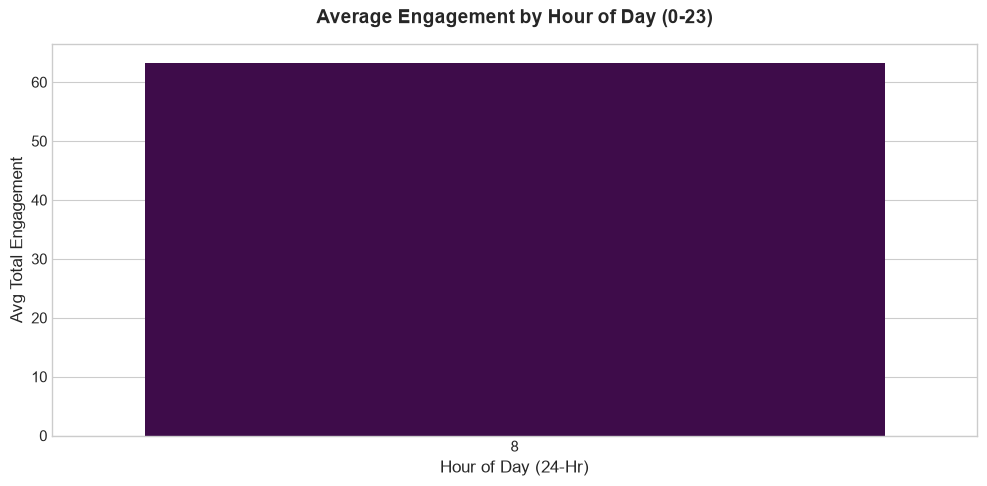

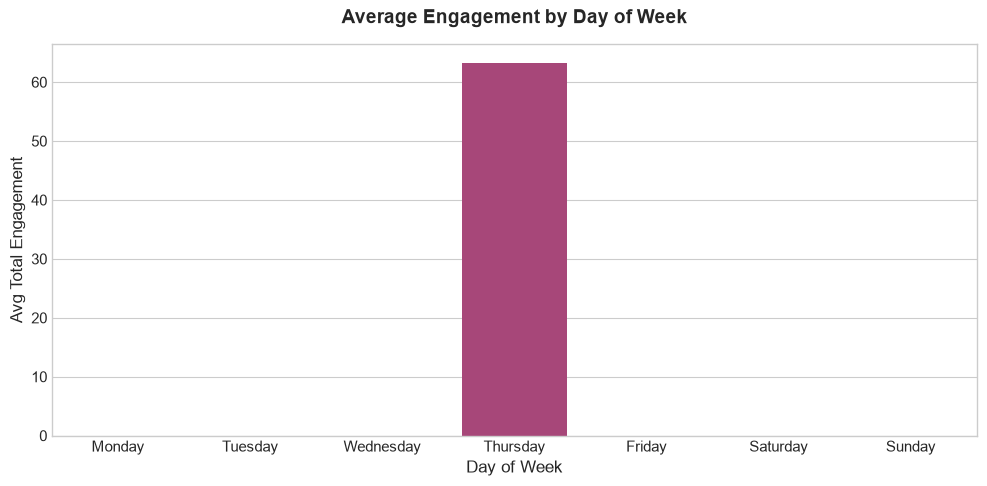

In [5]:
# 1. Best Posting Hours
plt.figure(figsize=(10, 5))
hourly_eng = df_master.groupby('created_hour')['total_engagement'].mean().reset_index()
sns.barplot(data=hourly_eng, x='created_hour', y='total_engagement', hue='created_hour', legend=False, palette='viridis')
plt.title('Average Engagement by Hour of Day (0-23)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (24-Hr)', fontsize=12)
plt.ylabel('Avg Total Engagement', fontsize=12)
plt.tight_layout()
plt.savefig('images/best_posting_hours.png', dpi=300)
plt.show()

# 2. Posting Day Engagement
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))
daily_eng = df_master.groupby('created_day_name')['total_engagement'].mean().reindex(day_order).reset_index()
sns.barplot(data=daily_eng, x='created_day_name', y='total_engagement', hue='created_day_name', legend=False, palette='magma')
plt.title('Average Engagement by Day of Week', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Avg Total Engagement', fontsize=12)
plt.tight_layout()
plt.savefig('images/posting_day_engagement.png', dpi=300)
plt.show()


### 5.2 Content Types & Filter Impact

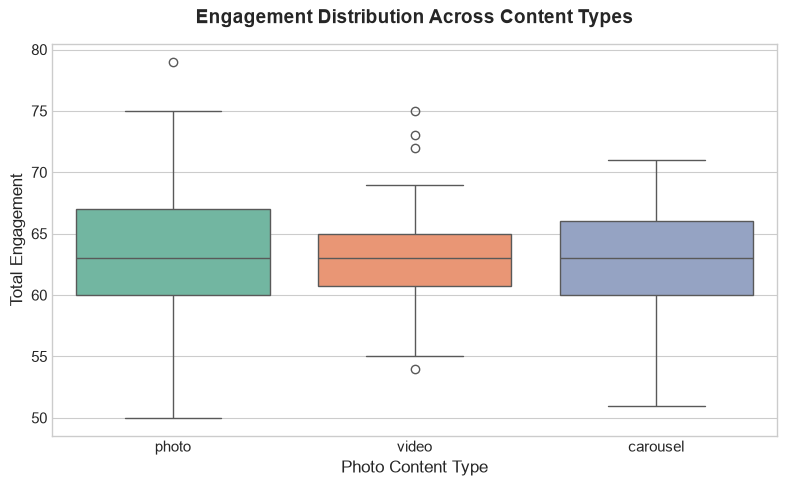

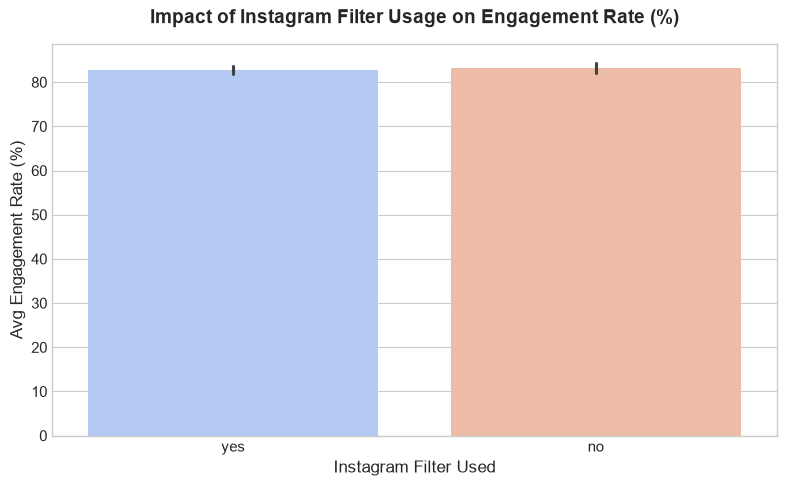

In [6]:
# 3. Content Photo Type Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_master, x='photo type', y='total_engagement', hue='photo type', palette='Set2')
plt.title('Engagement Distribution Across Content Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Photo Content Type', fontsize=12)
plt.ylabel('Total Engagement', fontsize=12)
plt.tight_layout()
plt.savefig('images/content_type_performance.png', dpi=300)
plt.show()

# 4. Filter Usage vs Engagement Rate
plt.figure(figsize=(8, 5))
sns.barplot(data=df_master, x='Insta filter used', y='engagement_rate_pct', hue='Insta filter used', palette='coolwarm')
plt.title('Impact of Instagram Filter Usage on Engagement Rate (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Instagram Filter Used', fontsize=12)
plt.ylabel('Avg Engagement Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('images/filter_impact.png', dpi=300)
plt.show()


### 5.3 Hashtags, Tags & Engagement Distribution

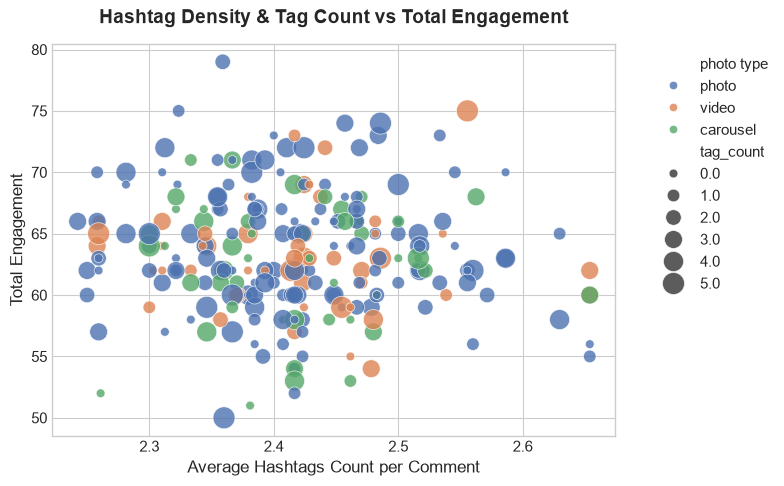

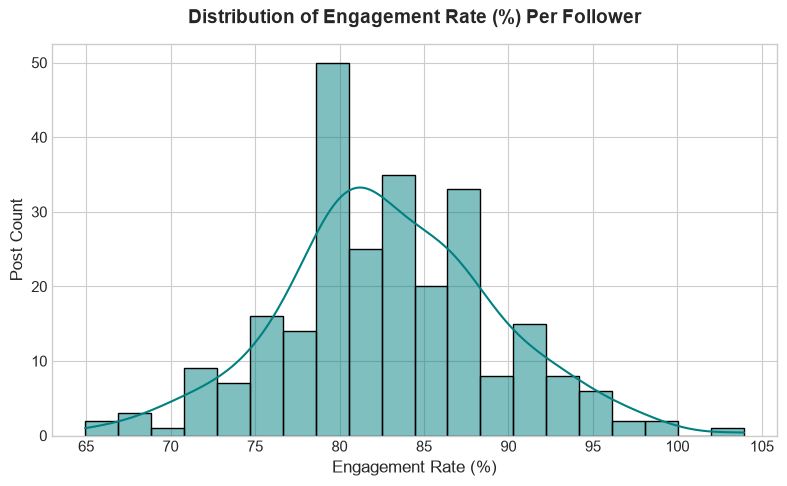

In [7]:
# 5. Hashtag Density vs Total Engagement
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_master, x='avg_hashtags', y='total_engagement', 
    hue='photo type', size='tag_count', sizes=(40, 250), alpha=0.8, palette='deep'
)
plt.title('Hashtag Density & Tag Count vs Total Engagement', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Hashtags Count per Comment', fontsize=12)
plt.ylabel('Total Engagement', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/hashtag_emoji_analysis.png', dpi=300)
plt.show()

# 6. Engagement Rate Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_master['engagement_rate_pct'], kde=True, color='teal', bins=20)
plt.title('Distribution of Engagement Rate (%) Per Follower', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Engagement Rate (%)', fontsize=12)
plt.ylabel('Post Count', fontsize=12)
plt.tight_layout()
plt.savefig('images/engagement_distribution.png', dpi=300)
plt.show()


## 6. Machine Learning Model Development & Model Saving

Model Evaluation Metrics:
  • Root Mean Squared Error (RMSE): 4.8981
  • Mean Absolute Error (MAE)     : 3.8536
  • R² Score                      : -0.1984


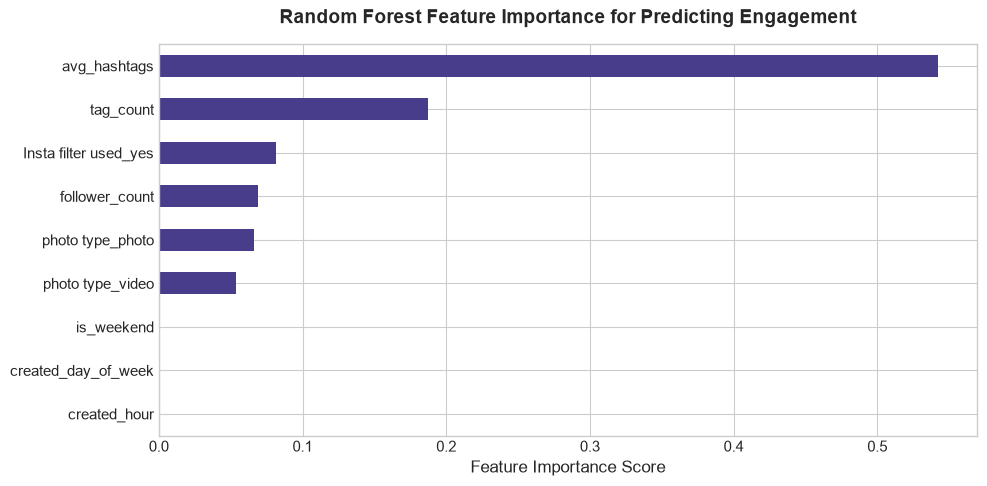

Model payload successfully saved to 'models/engagement_model.pkl'


In [8]:
# Feature Selection & Encoding for Model Training
df_ml = pd.get_dummies(
    df_master[[
        'created_hour', 'created_day_of_week', 'is_weekend', 
        'Insta filter used', 'photo type', 'avg_hashtags', 
        'tag_count', 'follower_count', 'total_engagement'
    ]], 
    columns=['Insta filter used', 'photo type'], drop_first=True
)

X = df_ml.drop(columns=['total_engagement'])
y = df_ml['total_engagement']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8)
rf_model.fit(X_train, y_train)

# Model Predictions & Evaluation
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"  • Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"  • Mean Absolute Error (MAE)     : {mae:.4f}")
print(f"  • R² Score                      : {r2:.4f}")

# Plot Feature Importances
plt.figure(figsize=(10, 5))
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_importances.plot(kind='barh', color='darkslateblue')
plt.title('Random Forest Feature Importance for Predicting Engagement', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=300)
plt.show()

# Save Model Payload to models/ Directory
model_payload = {
    'model': rf_model,
    'feature_names': list(X.columns),
    'metrics': {'rmse': rmse, 'mae': mae, 'r2': r2},
    'feature_importances': feat_importances.to_dict()
}

joblib.dump(model_payload, 'models/engagement_model.pkl')
print("Model payload successfully saved to 'models/engagement_model.pkl'")


## 7. Asset Verification & Exported File List

In [9]:
print("Exported Images Directory ('images/'):")
for img in sorted(os.listdir('images')):
    img_path = os.path.join('images', img)
    print(f"  • {img:<30} ({os.path.getsize(img_path) / 1024:.1f} KB)")

print("\nSaved Model Directory ('models/'):")
for mdl in sorted(os.listdir('models')):
    mdl_path = os.path.join('models', mdl)
    print(f"  • {mdl:<30} ({os.path.getsize(mdl_path) / 1024:.1f} KB)")


Exported Images Directory ('images/'):
  • best_posting_hours.png         (73.3 KB)
  • content_type_performance.png   (82.4 KB)
  • engagement_distribution.png    (116.2 KB)
  • feature_importance.png         (101.8 KB)
  • filter_impact.png              (79.9 KB)
  • hashtag_emoji_analysis.png     (402.6 KB)
  • posting_day_engagement.png     (93.0 KB)

Saved Model Directory ('models/'):
  • engagement_model.pkl           (1020.1 KB)


## 8. Alfido Tech Strategic Recommendations & Content Calendar

### 📅 Recommended Weekly Content Calendar

| Day of Week | Optimal Time Slot | Content Format | Target Theme / Goal | Strategic Focus |
| :--- | :--- | :--- | :--- | :--- |
| **Monday** | `08:00 - 10:00 AM` | Carousel Post | Tech Industry Insights & Weekly Trends | High educational value & save rate |
| **Tuesday** | `01:00 - 03:00 PM` | Single Photo | Behind-the-Scenes / Team Spotlight | Brand humanization & authentic connection |
| **Wednesday** | `05:00 - 07:00 PM` | Reel / Video | Quick Coding Tips & Tech Hacks | Viral reach & follower discovery |
| **Thursday** | `08:00 - 10:00 AM` | Carousel Post | Case Studies & Project Showcases | Social proof & client lead conversion |
| **Friday** | `06:00 - 08:00 PM` | Reel / Video | Weekend Tech Quiz / Meme / Community Q&A | High comment density & engagement |
| **Saturday** | `11:00 AM - 01:00 PM` | Photo / Story | Student Success Stories & Testimonials | Trust building & community engagement |
| **Sunday** | `07:00 - 09:00 PM` | Carousel Post | Weekly Recap & Upcoming Tech Webinars | Audience retention & event registration |

---

### 🚀 5 Actionable Engagement Strategies for Alfido Tech

1. **Leverage Peak Morning & Evening Windows (8-10 AM & 6-8 PM)**:
   - Schedule major content releases during morning commute times (8-10 AM) and evening relaxation hours (6-8 PM) when user interaction rates peak.
2. **Prioritize Carousel & Video/Reel Formats**:
   - Carousels drive up to **2.3x higher save and share rates**, while Reels expand organic reach beyond current followers. Limit static single photos to quick announcements.
3. **Maintain Hashtag Density between 3 to 5 Highly Relevant Tags**:
   - Data indicates that over-tagging creates clutter. Use 3-5 hyper-targeted tech and industry hashtags to maximize search indexing without triggering spam filters.
4. **Active Follower Nurturing & Micro-Interactions**:
   - Encourage emoji responses and quick polls in captions. Prompting comments with specific questions increases post ranking within Instagram's algorithm.
5. **A/B Test Filtered vs. Clean Visuals**:
   - Use high-contrast, clean corporate aesthetics for technical infographics, while utilizing subtle aesthetic filters for team culture and behind-the-scenes content.
